In [1]:
!pip install streamlit pandas numpy scikit-learn matplotlib seaborn joblib pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 100.2 MB/s eta 0:00:00


Original shape: (395, 33)
Accuracy: 91.14%
              precision    recall  f1-score   support

           0       0.83      0.93      0.88        27
           1       0.96      0.90      0.93        52

    accuracy                           0.91        79
   macro avg       0.90      0.91      0.90        79
weighted avg       0.92      0.91      0.91        79



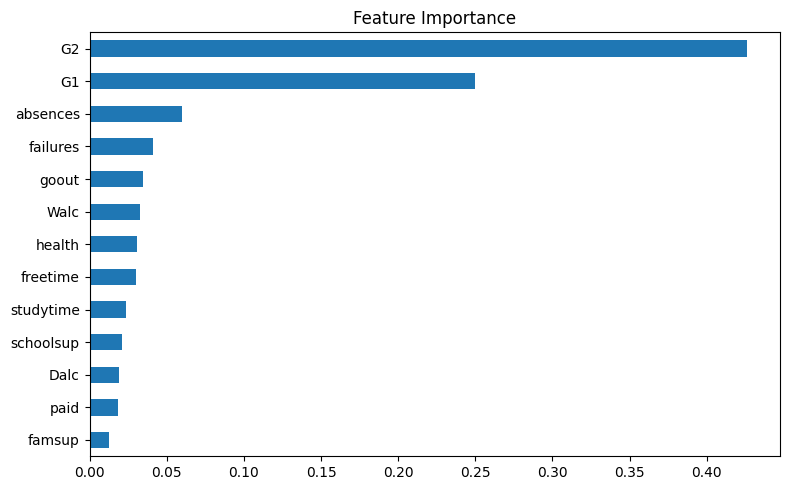

Model and scaler saved.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Load data
df = pd.read_csv('student_data.csv')
print("Original shape:", df.shape)

# Encode categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Create target: pass if G3 >= 10
df['target'] = (df['G3'] >= 10).astype(int)

# Feature selection (as per project requirements)
feature_cols = ['studytime', 'absences', 'G1', 'G2', 'freetime', 'health',
                'goout', 'Dalc', 'Walc', 'failures', 'schoolsup', 'famsup', 'paid']

X = df[feature_cols]
y = df['target']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")
print(classification_report(y_test, y_pred))

# Feature importance plot
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind='barh', figsize=(8,5))
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

# Save model and scaler for the Streamlit app
joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and scaler saved.")

In [5]:
app_code = """
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Load model and scaler
model = joblib.load('model.pkl')
scaler = joblib.load('scaler.pkl')

st.set_page_config(page_title="Student Success Prediction App", layout="centered")
st.title("🎓 Student Success Prediction App")
st.markdown("### Enter student details below to predict academic risk")

col1, col2 = st.columns(2)
with col1:
    studytime = st.slider("Weekly study time (1=<2h, 4=>10h)", 1, 4, 2)
    absences = st.number_input("Number of absences", 0, 93, 5)
    G1 = st.slider("First period grade (G1)", 0, 20, 10)
    G2 = st.slider("Second period grade (G2)", 0, 20, 10)
    freetime = st.slider("Free time after school (1=low, 5=high)", 1, 5, 3)
with col2:
    health = st.slider("Health status (1=very bad, 5=very good)", 1, 5, 3)
    goout = st.slider("Going out with friends (1=low, 5=high)", 1, 5, 3)
    Dalc = st.slider("Workday alcohol consumption (1=low, 5=high)", 1, 5, 2)
    Walc = st.slider("Weekend alcohol consumption (1=low, 5=high)", 1, 5, 2)
    failures = st.selectbox("Past class failures", [0,1,2,3])
    schoolsup = st.selectbox("Extra educational support", [0,1], format_func=lambda x: "Yes" if x==1 else "No")
    famsup = st.selectbox("Family educational support", [0,1], format_func=lambda x: "Yes" if x==1 else "No")
    paid = st.selectbox("Paid tutoring", [0,1], format_func=lambda x: "Yes" if x==1 else "No")

if st.button("🔍 Predict Student Success"):
    input_data = np.array([[studytime, absences, G1, G2, freetime, health,
                            goout, Dalc, Walc, failures, schoolsup, famsup, paid]])
    input_scaled = scaler.transform(input_data)
    pred = model.predict(input_scaled)[0]
    prob = model.predict_proba(input_scaled)[0][pred]
    st.markdown("---")
    if pred == 1:
        st.success(f"✅ **Good Standing!** High Grade predicted (probability: {prob:.2f})")
        st.balloons()
    else:
        st.error(f"⚠️ **High Risk!** Low Grade predicted (probability: {prob:.2f})")
        st.snow()
"""

with open('app.py', 'w') as f:
    f.write(app_code)
print("app.py created")

app.py created
